In [1]:
import pandas as pd

# Create dataset
data = {
    "Student_ID": [1, 2, 3],
    "Study_Hours": [6.5, 8.0, 5.0],
    "Sleep_Hours": [7.2, 6.5, 8.0],
    "Attendance": [85, 96, 77],
    "Exam_Score": [78, 88, 70]
}

df = pd.DataFrame(data)
df

,Student_ID,Study_Hours,Sleep_Hours,Attendance,Exam_Score
0,1,6.5,7.2,85,78
1,2,8.0,6.5,96,88
2,3,5.0,8.0,77,70


In [2]:
df["Self_Study_Hours"] = [2, 3, 1.5]
df

,Student_ID,Study_Hours,Sleep_Hours,Attendance,Exam_Score,Self_Study_Hours
0,1,6.5,7.2,85,78,2.0
1,2,8.0,6.5,96,88,3.0
2,3,5.0,8.0,77,70,1.5


In [3]:
# Summary statistics
print(df.describe())

# Correlation
print(df.corr())

       Student_ID  Study_Hours  Sleep_Hours  Attendance  Exam_Score  \
count         3.0         3.00     3.000000    3.000000    3.000000   
mean          2.0         6.50     7.233333   86.000000   78.666667   
std           1.0         1.50     0.750555    9.539392    9.018500   
min           1.0         5.00     6.500000   77.000000   70.000000   
25%           1.5         5.75     6.850000   81.000000   74.000000   
50%           2.0         6.50     7.200000   85.000000   78.000000   
75%           2.5         7.25     7.600000   90.500000   83.000000   
max           3.0         8.00     8.000000   96.000000   88.000000   

       Self_Study_Hours  
count          3.000000  
mean           2.166667  
std            0.763763  
min            1.500000  
25%            1.750000  
50%            2.000000  
75%            2.500000  
max            3.000000  
                  Student_ID  Study_Hours  Sleep_Hours  Attendance  \
Student_ID          1.000000    -0.500000     0.532939  

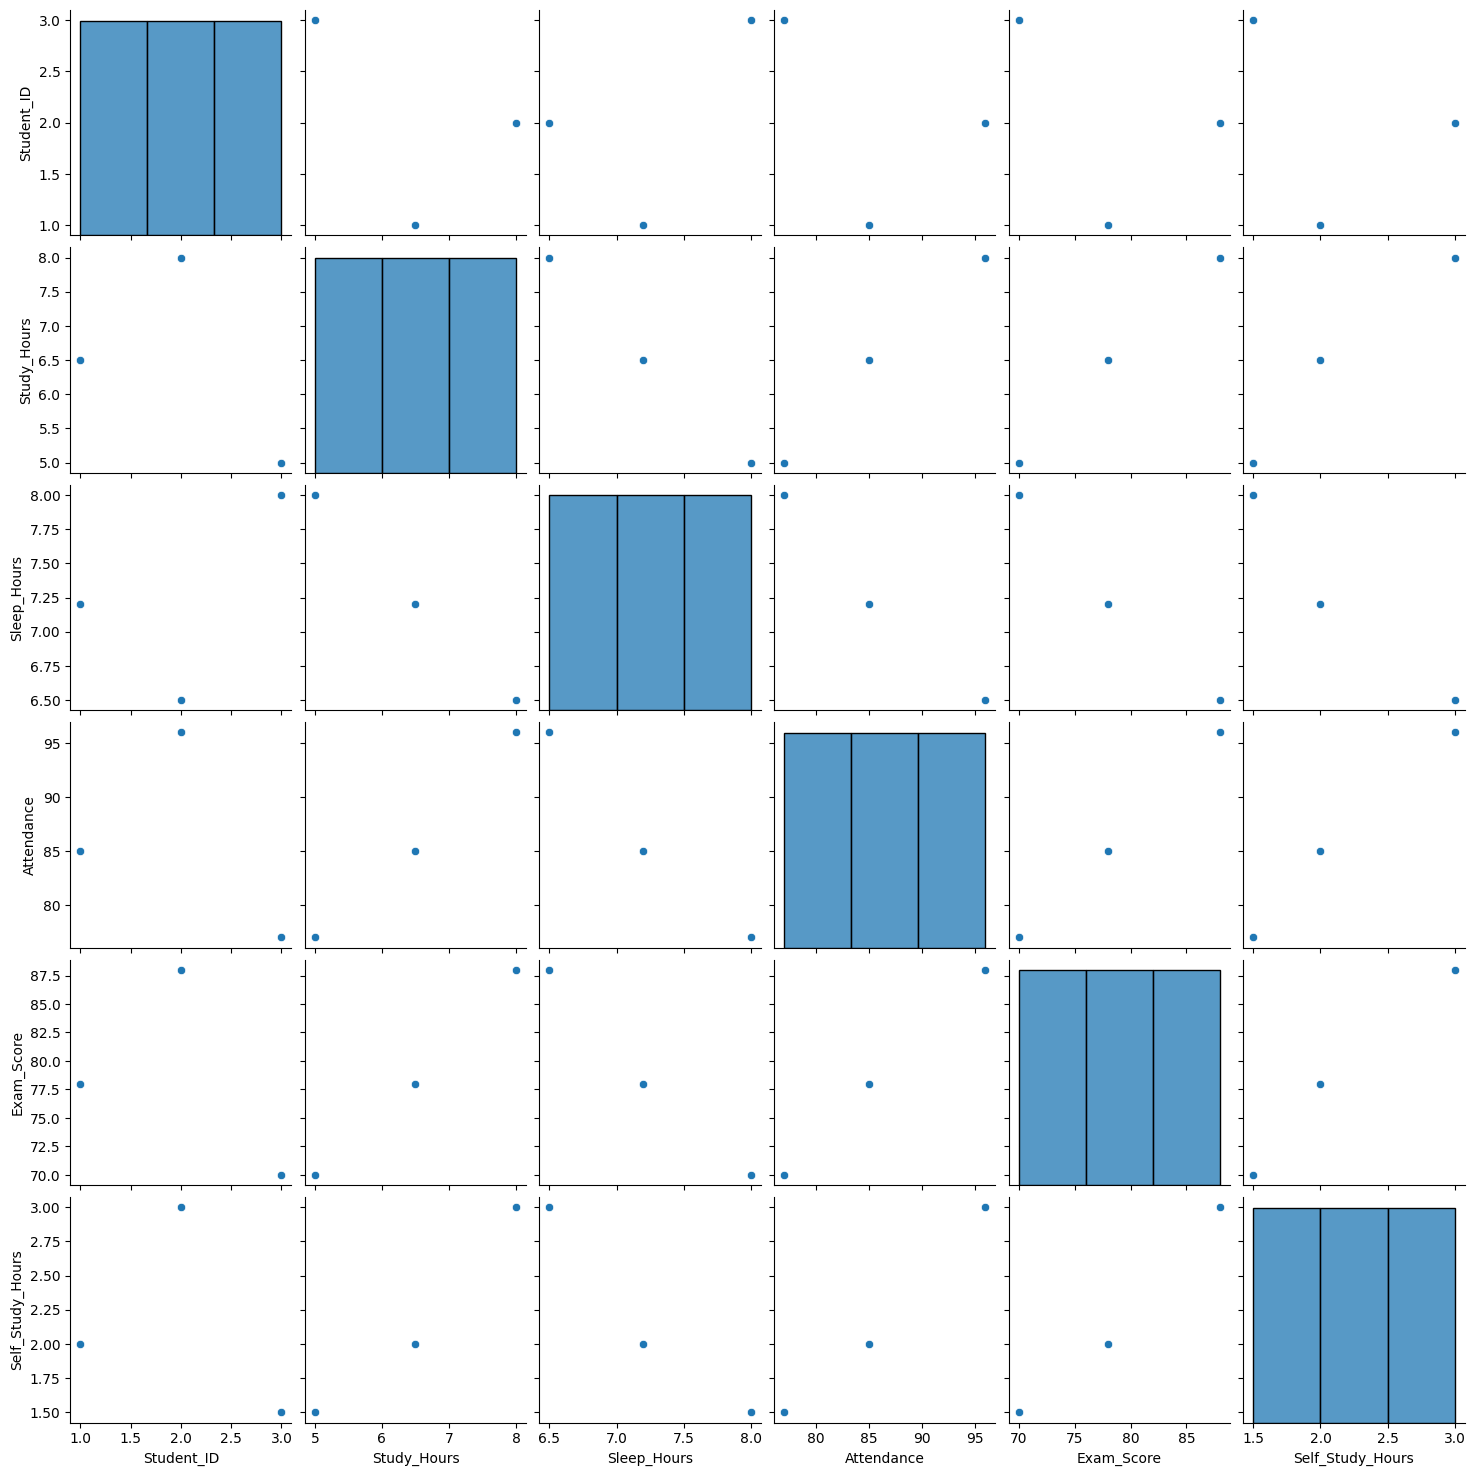

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.pairplot(df)
plt.show()

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [7]:
import statsmodels.api as sm

X_train_sm = sm.add_constant(X_train)  # add intercept
model = sm.OLS(y_train, X_train_sm).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:             Exam_Score   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                    nan
Method:                 Least Squares   F-statistic:                       nan
Date:                Thu, 02 Apr 2026   Prob (F-statistic):                nan
Time:                        10:40:09   Log-Likelihood:                 60.932
No. Observations:                   2   AIC:                            -117.9
Df Residuals:                       0   BIC:                            -120.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const               -0.0022        inf  

/usr/local/lib/python3.12/dist-packages/statsmodels/stats/stattools.py:125: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  skew = stats.skew(resids, axis=axis)
/usr/local/lib/python3.12/dist-packages/statsmodels/stats/stattools.py:126: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  kurtosis = 3 + stats.kurtosis(resids, axis=axis)
/usr/local/lib/python3.12/dist-packages/statsmodels/stats/stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 2 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "
/usr/local/lib/python3.12/dist-packages/statsmodels/regression/linear_model.py:1795: RuntimeWarning: divide by zero encountered in divide
  return 1 - (np.divide(self.nobs - se

In [12]:
X_test_sm = sm.add_constant(X_test, has_constant='add')
y_pred = model.predict(X_test_sm)

In [13]:
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("R2 Score:", r2)

MSE: 0.14213509163276458
R2 Score: nan


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)


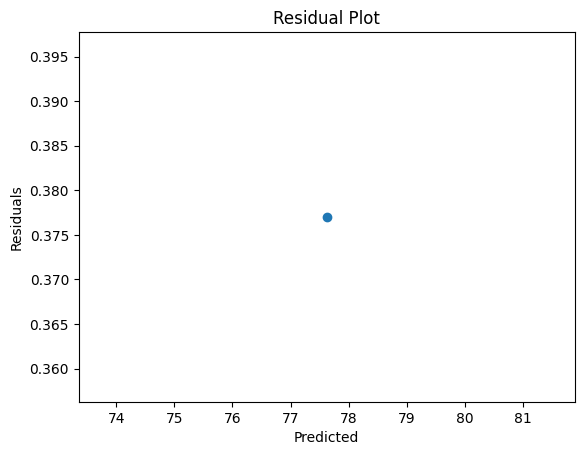

In [14]:
residuals = y_test - y_pred

plt.scatter(y_pred, residuals)
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

In [15]:
train_test_split(X, y, test_size=0.3, random_state=42)

[   Study_Hours  Sleep_Hours  Attendance  Self_Study_Hours
 1          8.0          6.5          96               3.0
 2          5.0          8.0          77               1.5,
    Study_Hours  Sleep_Hours  Attendance  Self_Study_Hours
 0          6.5          7.2          85               2.0,
 1    88
 2    70
 Name: Exam_Score, dtype: int64,
 0    78
 Name: Exam_Score, dtype: int64]

In [22]:
X_new = df[["Study_Hours", "Attendance"]]  # removed Sleep_Hours

X_train, X_test, y_train, y_test = train_test_split(X_new, y, test_size=0.3, random_state=42)

In [23]:
import statsmodels.api as sm

X_train_sm = sm.add_constant(X_train)  # add intercept
model = sm.OLS(y_train, X_train_sm).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:             Exam_Score   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                    nan
Method:                 Least Squares   F-statistic:                       nan
Date:                Thu, 02 Apr 2026   Prob (F-statistic):                nan
Time:                        10:51:03   Log-Likelihood:                 57.514
No. Observations:                   2   AIC:                            -111.0
Df Residuals:                       0   BIC:                            -113.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const          -0.0373        inf         -0      

/usr/local/lib/python3.12/dist-packages/statsmodels/stats/stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 2 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "
/usr/local/lib/python3.12/dist-packages/statsmodels/regression/linear_model.py:1795: RuntimeWarning: divide by zero encountered in divide
  return 1 - (np.divide(self.nobs - self.k_constant, self.df_resid)
/usr/local/lib/python3.12/dist-packages/statsmodels/regression/linear_model.py:1795: RuntimeWarning: invalid value encountered in scalar multiply
  return 1 - (np.divide(self.nobs - self.k_constant, self.df_resid)
/usr/local/lib/python3.12/dist-packages/statsmodels/regression/linear_model.py:1717: RuntimeWarning: divide by zero encountered in scalar divide
  return np.dot(wresid, wresid) / self.df_resid


In [24]:
X_test_sm = sm.add_constant(X_test, has_constant='add')
y_pred = model.predict(X_test_sm)

In [25]:
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("R2 Score:", r2)

MSE: 0.10547173749817665
R2 Score: nan


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)


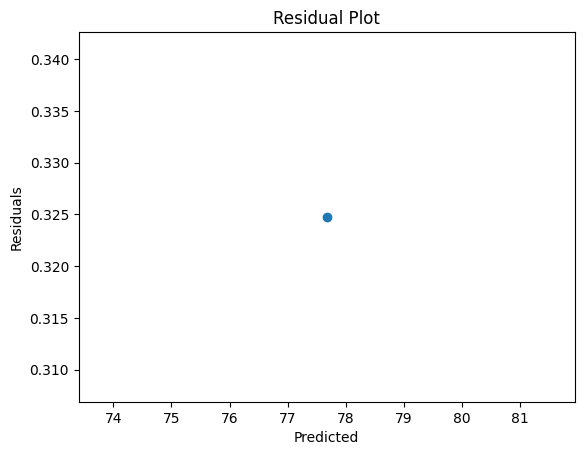

In [26]:
residuals = y_test - y_pred

plt.scatter(y_pred, residuals)
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()